In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append("../src/data/features")
from build_features import load_prices_long, add_log_returns, add_lagged_returns, add_rolling_volatility, add_rolling_z_score, add_rsi

In [2]:
tickers = ['SPY','GOOG', 'NVDA', 'NFLX', 'MSFT']
df = load_prices_long("../data/raw_prices.parquet", tickers)
df = add_log_returns(df)
df = add_lagged_returns(df)
print(df.head(10))


Price       date       open       high        low      close    volume ticker  \
887   2023-01-03  89.044922  90.749892  88.241996  88.916054  20738500   GOOG   
888   2023-01-04  90.214602  90.442587  87.032657  87.934700  27046500   GOOG   
889   2023-01-05  87.300299  87.439075  85.803494  86.011658  23136100   GOOG   
890   2023-01-06  86.596500  87.696799  84.822143  87.389511  26612600   GOOG   
891   2023-01-09  88.415455  90.036168  87.805832  88.023911  22996700   GOOG   
892   2023-01-10  85.962095  88.693015  85.942266  88.460068  22855600   GOOG   
893   2023-01-11  89.272897  91.642009  88.955694  91.453674  25998800   GOOG   
894   2023-01-12  91.592451  91.810529  89.778443  91.106735  22754200   GOOG   
895   2023-01-13  90.728074  92.167387  90.135301  91.988960  18630700   GOOG   
896   2023-01-17  91.969130  92.157472  90.046082  91.354553  22935800   GOOG   

Price  log_return  return1d  return5d  return10d  return20d  
887           NaN       NaN       NaN        N

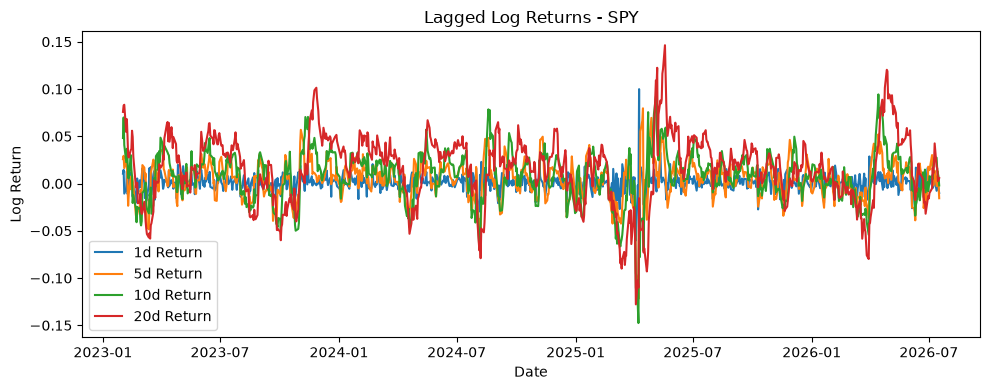

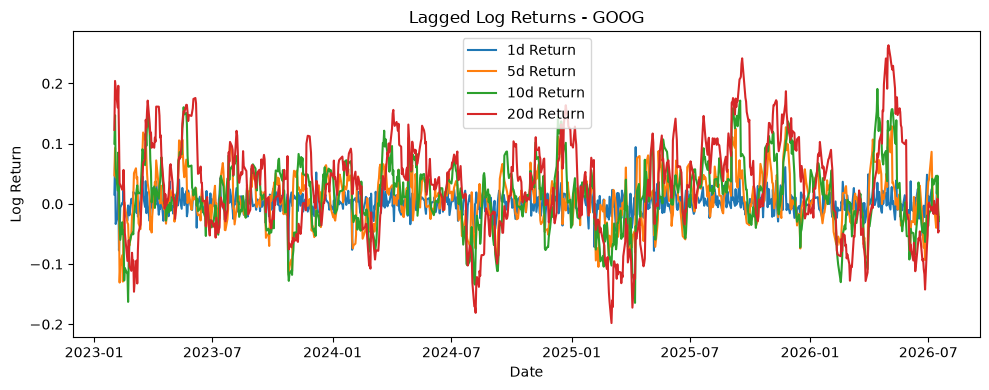

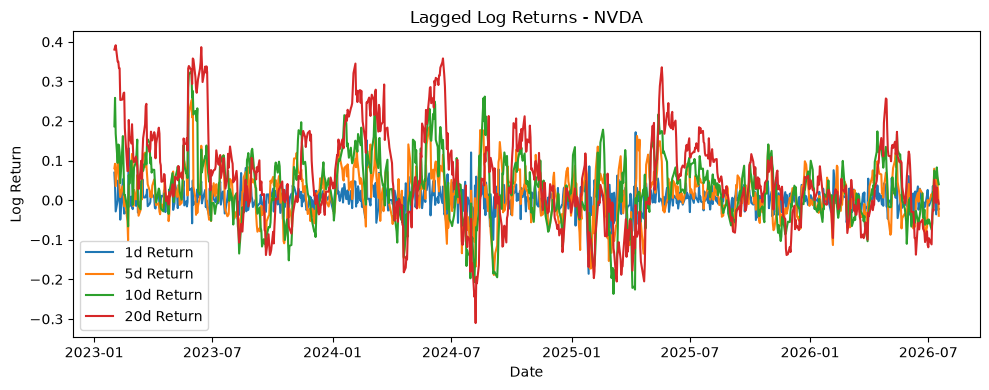

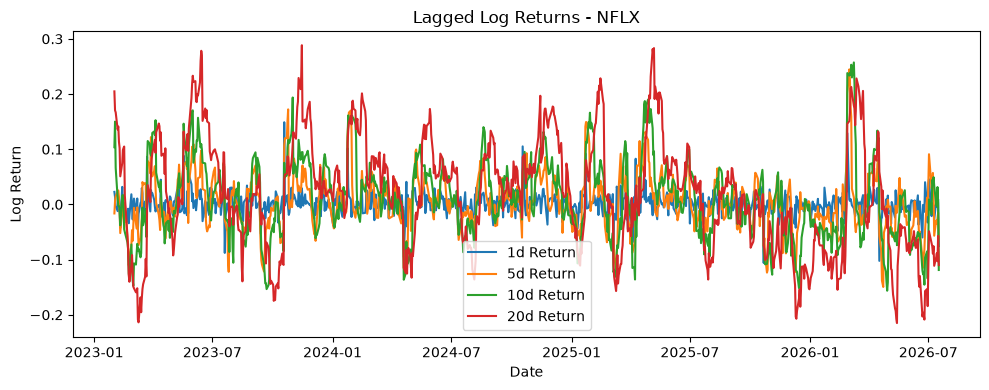

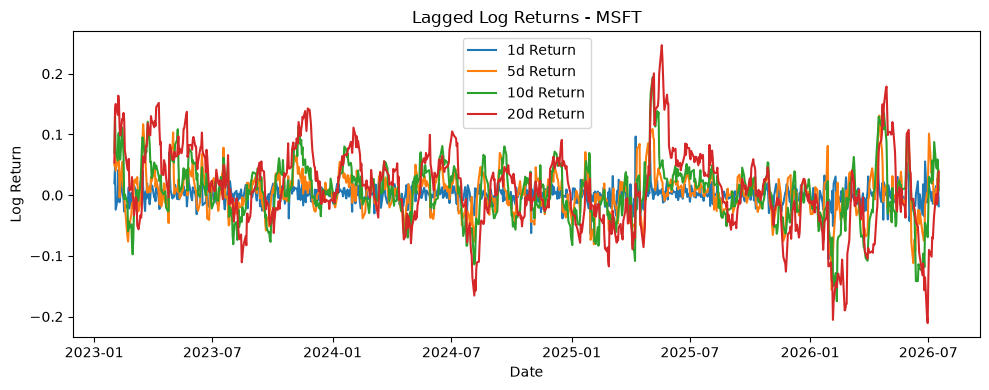

In [3]:
lags = [1, 5, 10, 20]

for t in tickers:
    # Filters row for current ticker
    sub_df = df[df['ticker'] == t].dropna()
    
    # Plot each return column using dat as index
    plt.figure(figsize=(10, 4))
    for lag in lags:
        plt.plot(sub_df['date'], sub_df[f'return{lag}d'], label=f'{lag}d Return')
        
    plt.title(f'Lagged Log Returns - {t}')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.legend()
    plt.tight_layout()  
    plt.show()

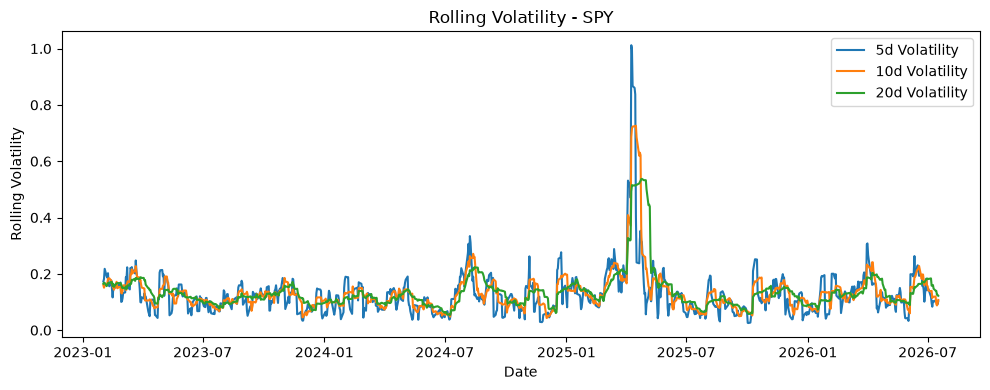

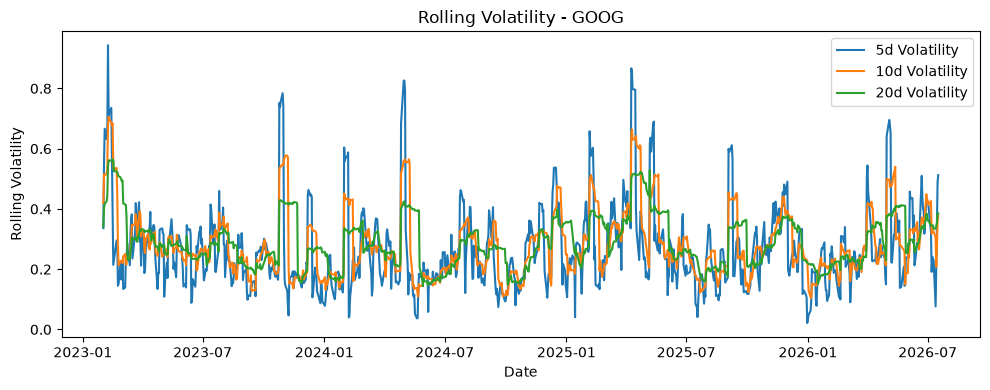

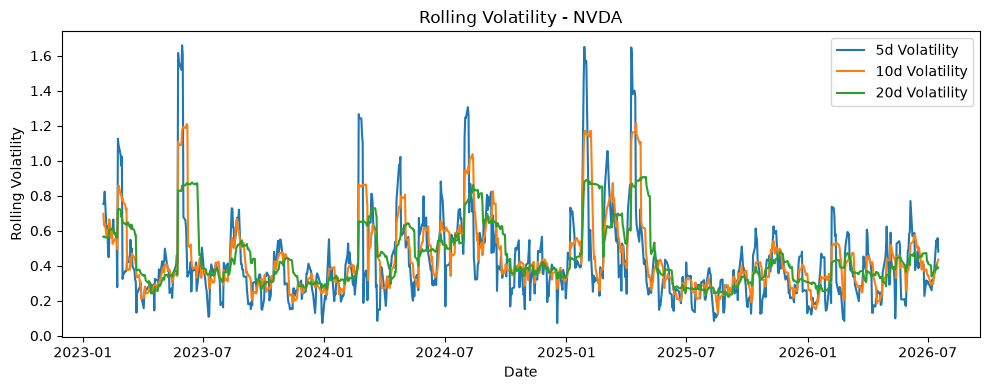

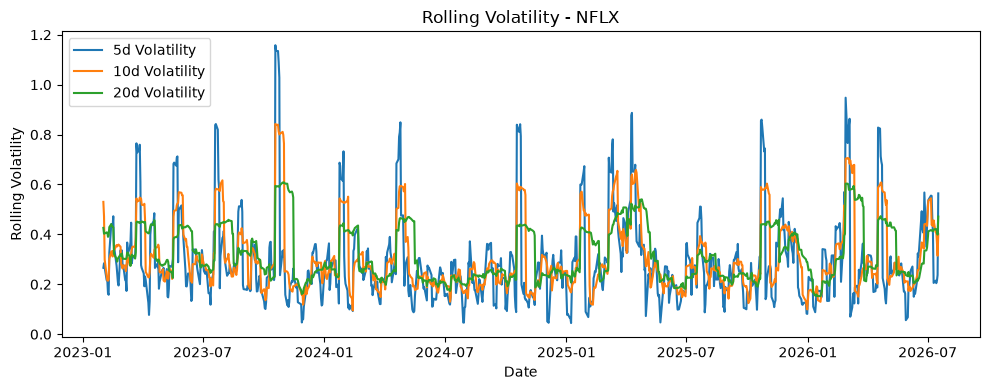

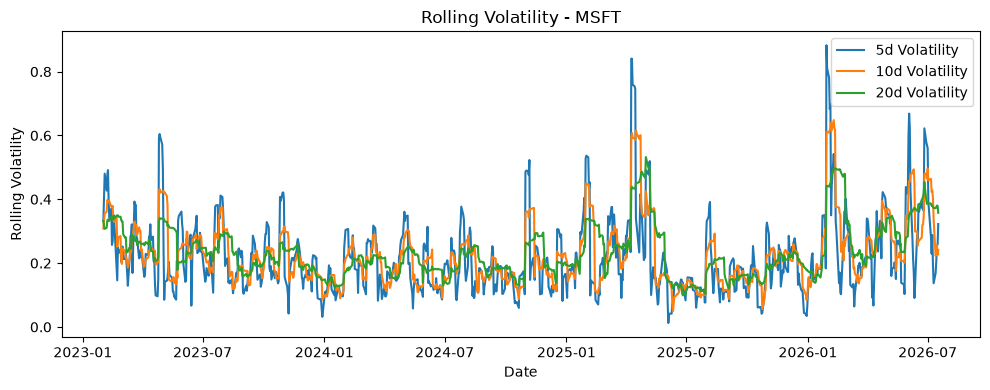

In [4]:
df = add_rolling_volatility(df)
windows = [5, 10, 20]

for t in tickers:
    # Filters row for current ticker
    sub_df = df[df['ticker'] == t].dropna()
    
    # Plot each return column using dat as index
    plt.figure(figsize=(10, 4))
    for v in windows:
        plt.plot(sub_df['date'], sub_df[f'vol_{v}d'], label=f'{v}d Volatility')
        
    plt.title(f'Rolling Volatility - {t}')
    plt.xlabel('Date')
    plt.ylabel('Rolling Volatility')
    plt.legend()
    plt.tight_layout()  
    plt.show()

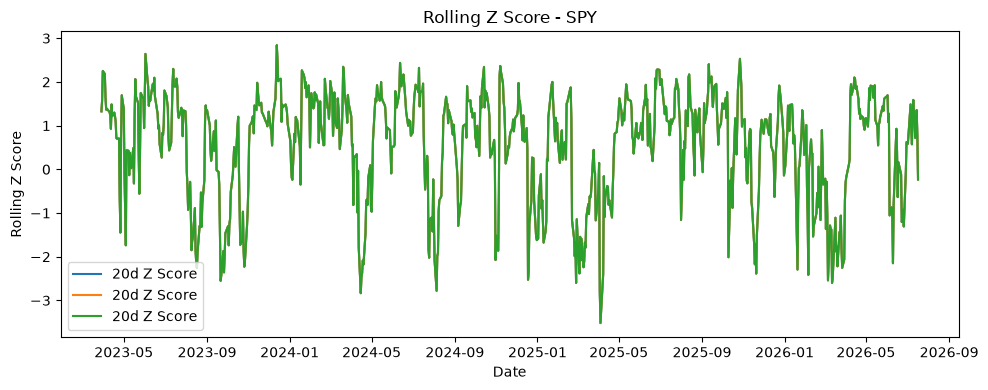

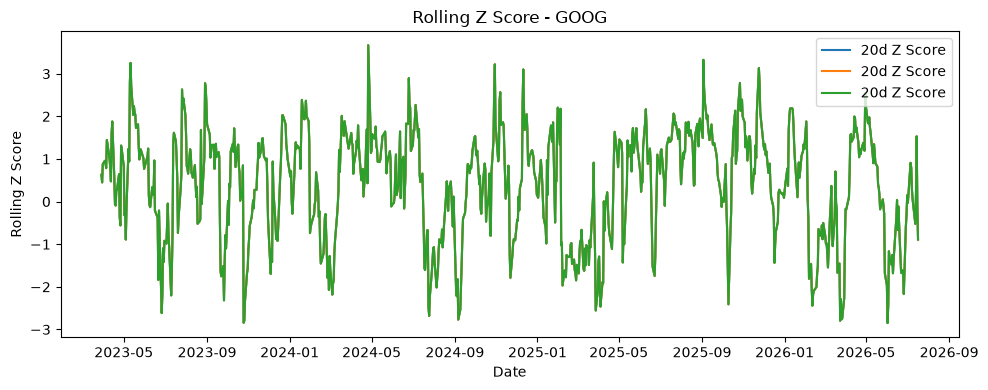

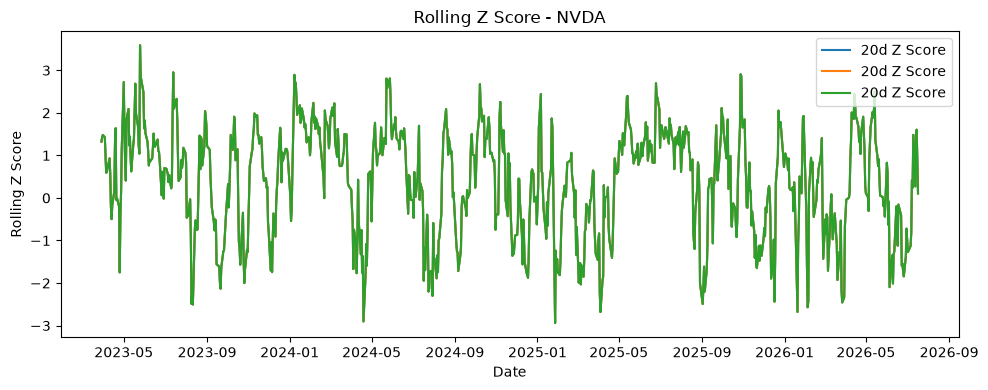

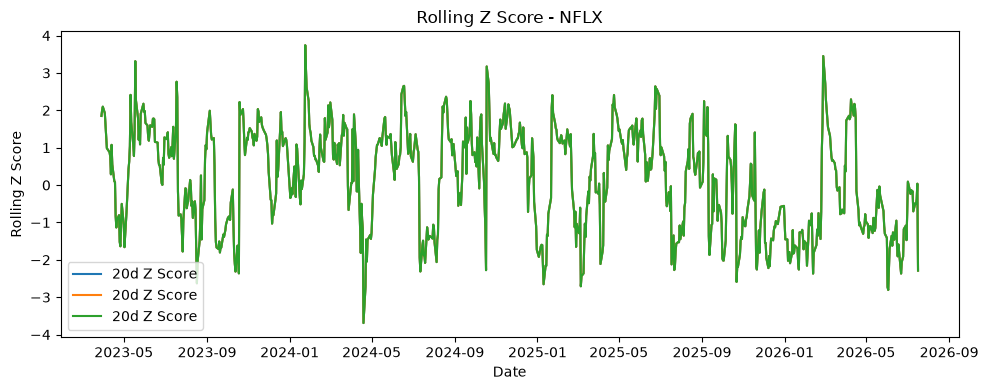

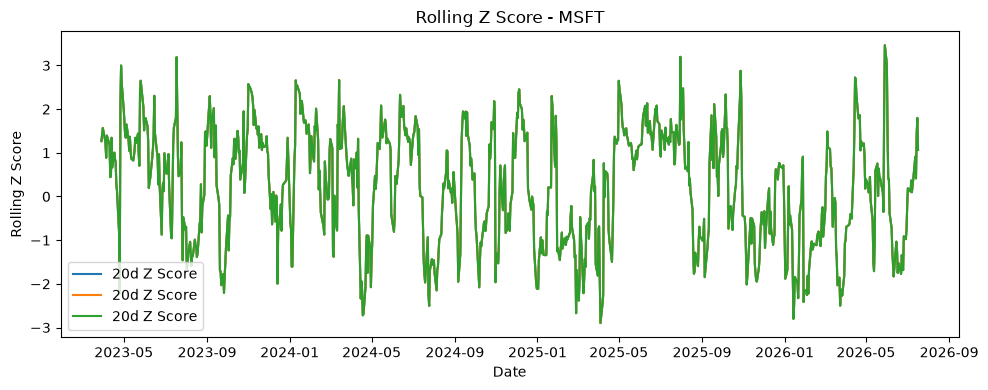

In [5]:
df = add_rolling_z_score(df)
windows = [5, 10, 20]

for t in tickers:
    # Filters row for current ticker
    sub_df = df[df['ticker'] == t].dropna()
    
    # Plot each return column using dat as index
    plt.figure(figsize=(10, 4))
    for z in windows:
        plt.plot(sub_df['date'], sub_df[f'z_{v}d'], label=f'{v}d Z Score')
        
    plt.title(f'Rolling Z Score - {t}')
    plt.xlabel('Date')
    plt.ylabel('Rolling Z Score')
    plt.legend()
    plt.tight_layout()  
    plt.show()

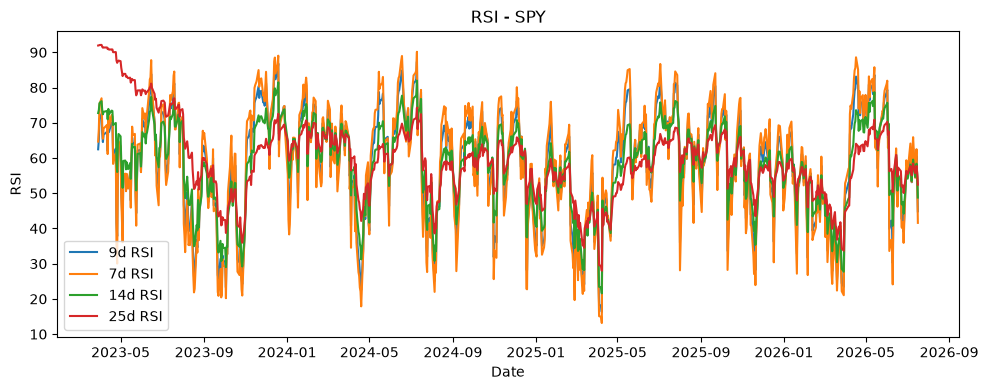

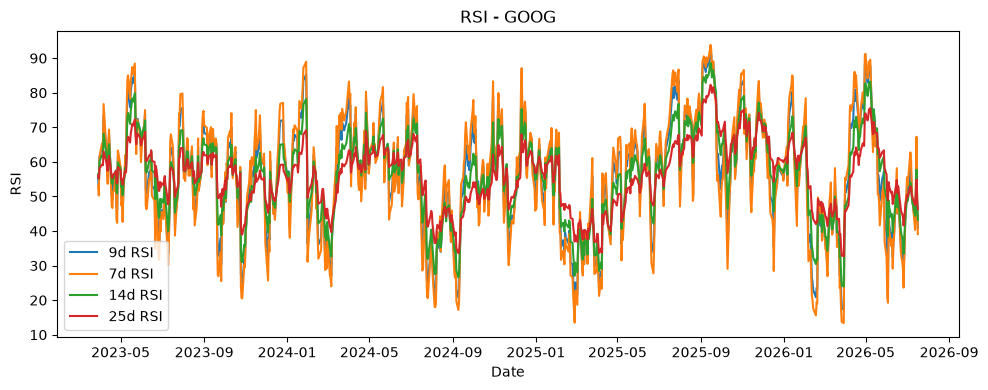

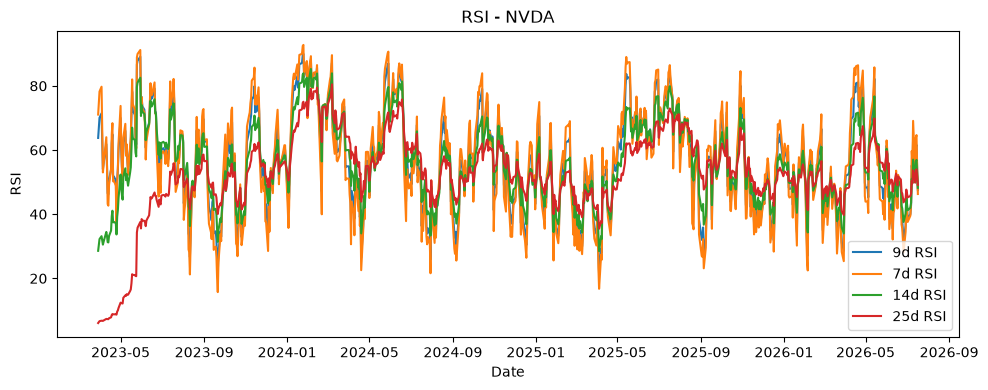

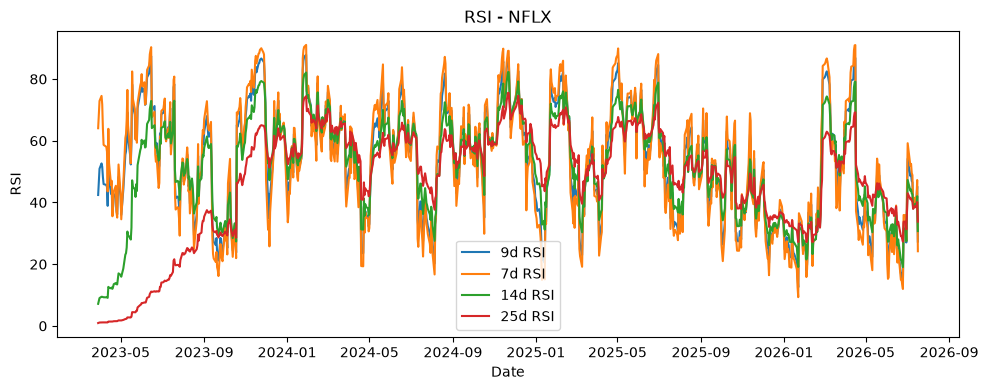

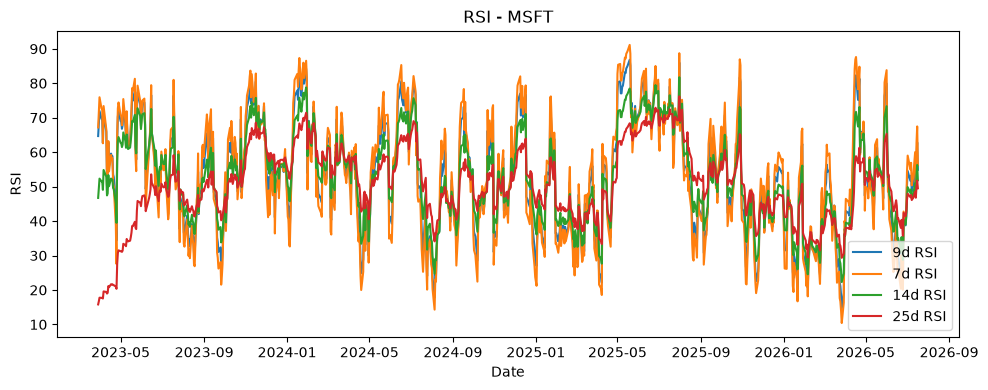

In [6]:
df = add_rsi(df)
windows = [9, 7, 14, 25]

for t in tickers:
    # Filters row for current ticker
    sub_df = df[df['ticker'] == t].dropna()
    
    # Plot each return column using date as index
    plt.figure(figsize=(10, 4))
    for r in windows:
        plt.plot(sub_df['date'], sub_df[f'rsi_{r}d'], label=f'{r}d RSI')
        
    plt.title(f'RSI - {t}')
    plt.xlabel('Date')
    plt.ylabel('RSI')
    plt.legend()
    plt.tight_layout()  
    plt.show()